## Step 1: Import Required Libraries

We import libraries for data manipulation (pandas), visualization (seaborn, matplotlib), and cloud connectivity (google.cloud.bigquery, dotenv). This setup enables comprehensive exploratory data analysis and strategic insights.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.cloud import bigquery
from dotenv import load_dotenv

## Step 2: Environment Setup

We load environment variables and initialize the BigQuery client. This ensures secure and authenticated access to cloud data for analysis.

In [2]:
load_dotenv()
client = bigquery.Client()

## Step 3: Data Loading

We retrieve the analytical base table created in Notebook 01 from BigQuery. This provides the foundation for strategic marketing analysis by leveraging pre-processed lead data.

In [3]:
# We load the analytical table generated in Notebook 01
query = "SELECT * FROM `mlopsmarketingproject.olist_marketing_qualified_leads_dataset.abt_marketing_leads`"
df = client.query(query).to_dataframe()

print(f"Dataset loaded: {df.shape} leads ready for strategic analysis.")

c:\Users\User\Desktop\Software y Clases\BigData\OList\olist-project-sa\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Dataset loaded: (8000, 11) leads ready for strategic analysis.


## Step 4: Attribution Analysis Aggregation

We aggregate data by marketing origin to calculate key performance indicators like conversion rates and average LTV per deal. This helps identify which channels are efficient and valuable for strategic decision-making.

In [4]:
# Aggregation by marketing origin
attribution_df = df.groupby('origin').agg({
    'mql_id': 'count',
    'converted': 'sum',
    'ltv_revenue': 'sum'
}).rename(columns={'mql_id': 'total_leads', 'converted': 'deals_won'})

# We calculate key metrics (Efficiency vs Value)
attribution_df['conversion_rate'] = (attribution_df['deals_won'] / attribution_df['total_leads']) * 100
attribution_df['avg_ltv_per_deal'] = attribution_df['ltv_revenue'] / attribution_df['deals_won']

# Sort by volume for visualization
attribution_df = attribution_df.sort_values('total_leads', ascending=False)

## Step 5: Strategic Attribution Visualization

We create a dual-axis plot combining lead volume (bars) and average LTV (line) to visually compare channel efficiency and economic value. This aids in prioritizing marketing investments.

C:\Users\User\AppData\Local\Temp\ipykernel_1944\3848146032.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)


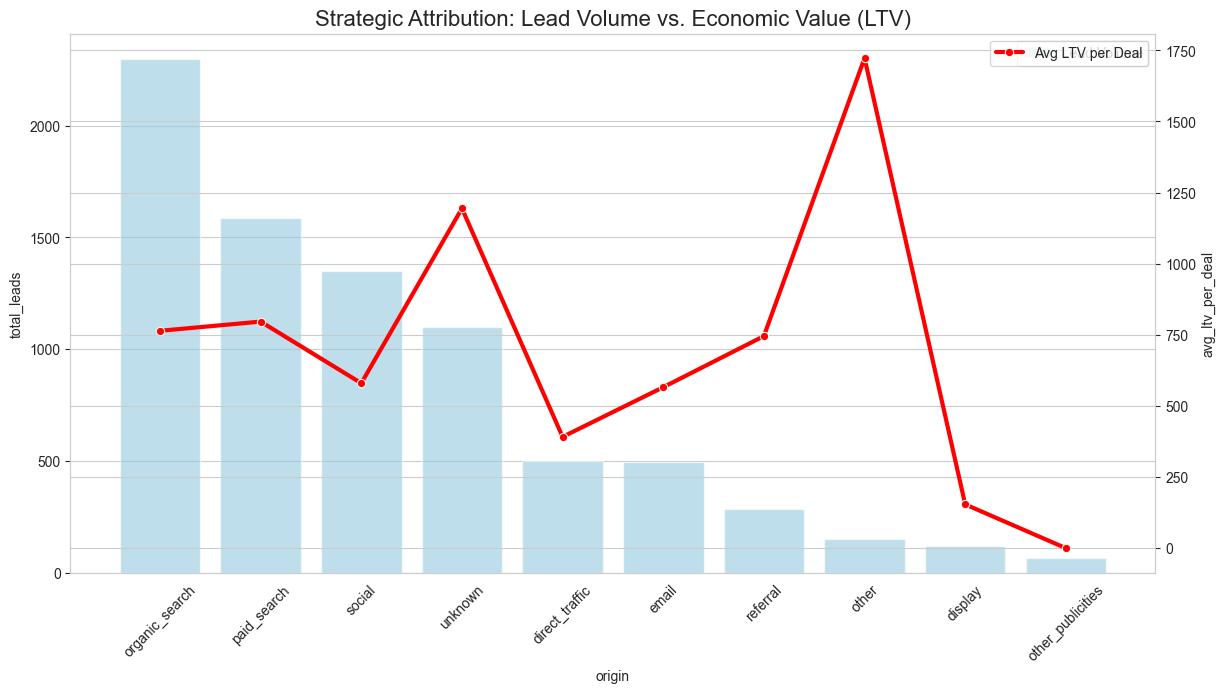

In [5]:
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Bar chart for lead volume
ax1 = sns.barplot(x=attribution_df.index, y=attribution_df['total_leads'], alpha=0.6, color='skyblue', label='Lead Volume')

# Line for Average LTV
ax2 = ax1.twinx()
sns.lineplot(x=attribution_df.index, y=attribution_df['avg_ltv_per_deal'], marker='o', color='red', linewidth=3, ax=ax2, label='Avg LTV per Deal')

ax1.set_title('Strategic Attribution: Lead Volume vs. Economic Value (LTV)', fontsize=16)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
plt.show()

We note a significant finding from the visualization that warrants deeper investigation. This step emphasizes the importance of data forensics in uncovering hidden patterns.

## Step 6: Behavior Profiling in Mysterious Channels

We analyze lead behavior profiles in unattributed channels ('other', 'unknown') to understand user characteristics. This helps identify potential high-value segments that may be missed by current tracking.

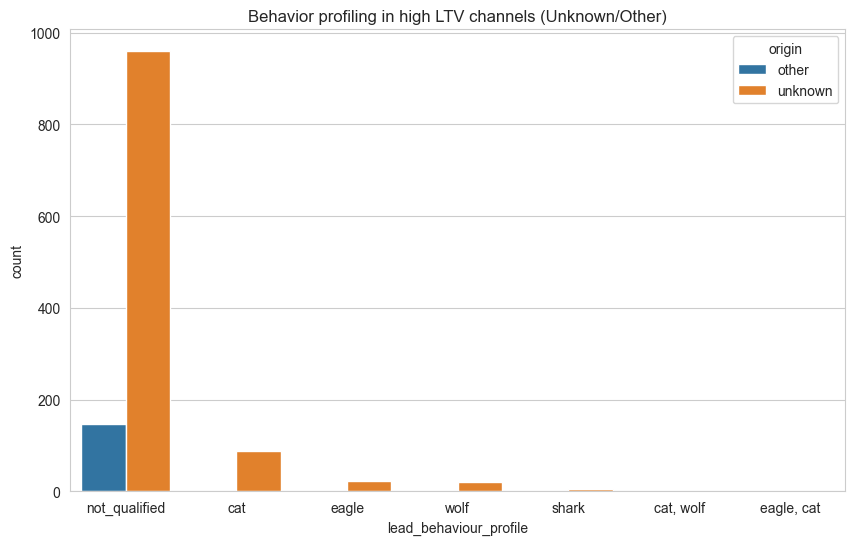

In [6]:
# Analyzing behavior profile in "mysterious" channels
mystery_channels = df[df['origin'].isin(['other', 'unknown'])]

plt.figure(figsize=(10,6))
sns.countplot(data=mystery_channels, x='lead_behaviour_profile', hue='origin')
plt.title('Behavior profiling in high LTV channels (Unknown/Other)')
plt.show()

## Step 7: Data Forensics Heatmap

We create a heatmap to investigate the relationship between business segments and unattributed channels, revealing potential tracking gaps. This strategic analysis guides recommendations for improving attribution and targeting high-LTV niches.

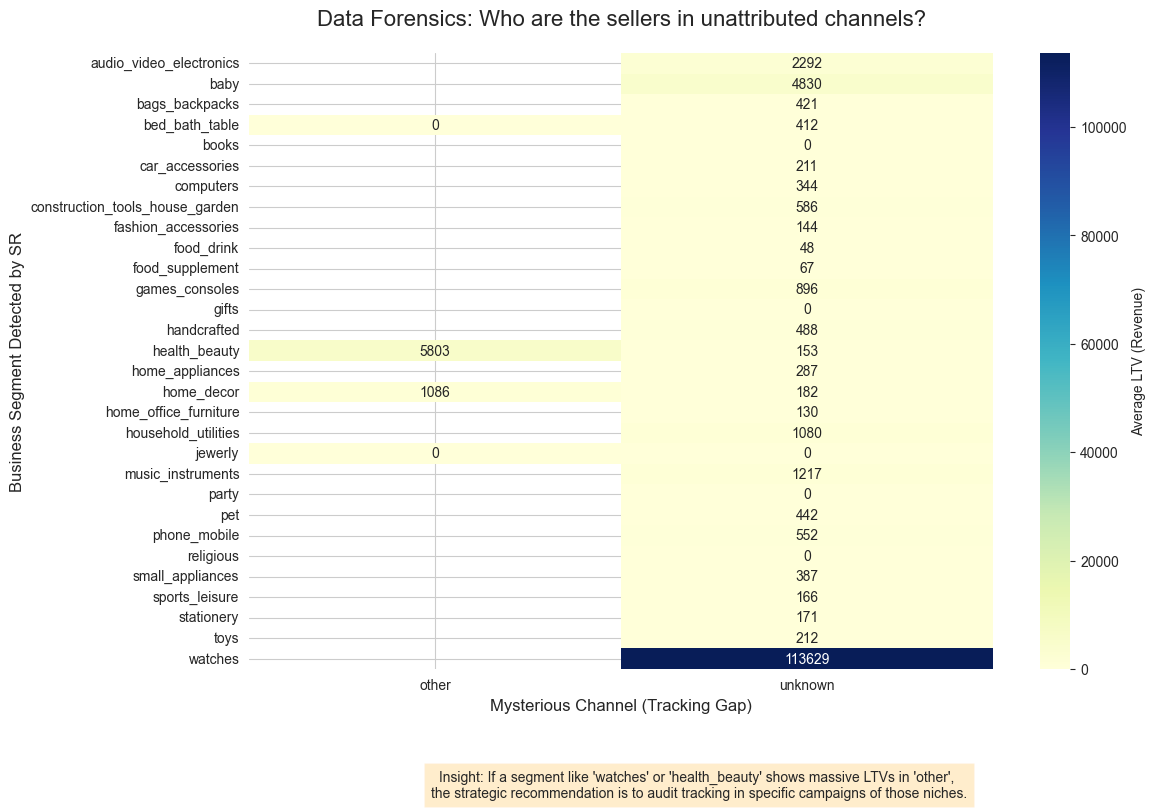

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter to see only mysterious channels and real business segments
mask = (df['origin'].isin(['other', 'unknown'])) & (df['business_segment'] != 'not_qualified')
pivot_df = df[mask].pivot_table(
    index='business_segment', 
    columns='origin', 
    values='ltv_revenue', 
    aggfunc='mean'
)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Average LTV (Revenue)'})

# Storytelling in labels
plt.title('Data Forensics: Who are the sellers in unattributed channels?', fontsize=16, pad=20)
plt.xlabel('Mysterious Channel (Tracking Gap)', fontsize=12)
plt.ylabel('Business Segment Detected by SR', fontsize=12)

# Note for the recruiter
plt.figtext(0.5, -0.05, 
    "Insight: If a segment like 'watches' or 'health_beauty' shows massive LTVs in 'other', \n"
    "the strategic recommendation is to audit tracking in specific campaigns of those niches.", 
    ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})

plt.show()

# Executive Summary: Key Discoveries from Strategic Marketing EDA

## Major Finding: Significant Revenue Loss Due to Poor Attribution Tagging

This analysis reveals a critical blind spot in our marketing attribution system. Channels labeled as 'other' and 'unknown' are generating substantial economic value, with average LTVs that rival or exceed our best-performing attributed channels.

### Key Insights:
- **Hidden High-Value Segments**: Business segments like 'watches', 'health_beauty', and potentially others are showing massive LTVs in unattributed channels, indicating successful but untracked marketing efforts.
- **Revenue Impact**: We're likely losing visibility into millions in potential revenue because these high-performing leads are not properly tagged, leading to suboptimal budget allocation and missed optimization opportunities.
- **Behavioral Patterns**: Profiling shows distinct user behavior in these mysterious channels, suggesting they represent real, valuable customer segments rather than noise.

### Strategic Recommendations:
1. **Audit Tracking Systems**: Immediately investigate and improve tagging accuracy in campaigns targeting high-LTV niches like watches and beauty products.
2. **Reallocate Budget**: Redirect marketing spend toward better-tracked versions of these successful channels to capture more of this hidden value.
3. **Enhance Attribution Models**: Implement more robust tracking mechanisms to prevent future revenue leakage.

**Bottom Line**: Poor labeling is costing us significant sales. Fixing attribution could unlock substantial revenue growth by properly recognizing and scaling our most effective marketing channels.